In [1]:
import cv2
import pdb
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import ipywidgets as widgets
import scipy.signal, scipy.misc
import plotly.graph_objects as go

from ipywidgets import interact, IntSlider, FloatSlider
from nilearn.maskers import NiftiLabelsMasker
from nilearn.interfaces.fmriprep import load_confounds
from nilearn import plotting, datasets, image, regions
from nilearn.connectome import ConnectivityMeasure
from nilearn.decoding import Decoder
from nilearn.image import mean_img, index_img
from nilearn.datasets import MNI152_FILE_PATH, load_mni152_template
from nilearn.interfaces.fmriprep import load_confounds_strategy
from nilearn.plotting import plot_glass_brain, view_img_on_surf, plot_epi, show, plot_roi, view_img
from nibabel.testing import data_path
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Image
from sklearn.model_selection import LeaveOneGroupOut
from skimage import data
from skimage.color import rgb2gray
from math import *
from pathlib import Path
from PIL import Image

C:\Users\deepa\AppData\Local\Temp\ipykernel_37348\2307532451.py:10: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.signal, scipy.misc


In [ ]:
import glob, math, random, time, copy
from collections import OrderedDict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from extract_slices import load_nifti as load_nifti_raw, create_submission_df

These are the utility functions we are going to use. The first one is load_nifiti which loads our .nii file and returns a numpy array containing the voxel data, which is then cast to float32 to ensure compatibilioty with torch training. It returns a resulting shape of (X,Y,Z) 3D mri volume.
Norm01 is the min max normalization function to train stably also the 1e-8 is to prevent division by 0 in case of constant image.
psnr01 computes between two images a and b, where we first coompute mse and if mse is too small that means images are almost identical so we return 50 otherwise we plug it in the formula below.
the upsample_lf_to_hf upsample the low field images to high field to map the lf images to create a baseline hf volume from an lf input.

In [ ]:
def load_nifti(path: str) -> np.ndarray:
    return nib.load(path).get_fdata().astype(np.float32)

def norm01(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    mn, mx = float(x.min()), float(x.max())
    return (x - mn) / (mx - mn + 1e-8)

def psnr01(a: np.ndarray, b: np.ndarray) -> float:
    mse = float(np.mean((a - b) ** 2))
    if mse < 1e-12:
        return 50.0
    return 10.0 * math.log10(1.0 / mse)

def upsample_lf_to_hf(lf_vol: np.ndarray, target_shape) -> np.ndarray:
    x = torch.from_numpy(lf_vol).unsqueeze(0).unsqueeze(0)      # (1,1,X,Y,Z)
    x = x.permute(0, 1, 4, 3, 2)                                # (1,1,Z,Y,X)

    tx, ty, tz = target_shape                                   # target is (X,Y,Z)
    y = F.interpolate(x, size=(tz, ty, tx), mode="trilinear", align_corners=False)

    y = y.permute(0, 1, 4, 3, 2).squeeze(0).squeeze(0)          # (X,Y,Z)
    return y.cpu().numpy().astype(np.float32)

This is a basic function to get the corresponding high_field for a low_field and pairing it to make a list of pairs.

In [4]:
def build_pairs(train_low_dir="./train/low_field", train_high_dir="./train/high_field"):
    low_paths = sorted(glob.glob(os.path.join(train_low_dir, "sample_*_lowfield.nii*")))
    pairs = []
    for lp in low_paths:
        base = os.path.basename(lp)
        sample_id = base.split("_lowfield")[0]  # "sample_001"

        hp_nii = os.path.join(train_high_dir, sample_id + "_highfield.nii")
        hp_gz  = hp_nii + ".gz"
        if os.path.exists(hp_nii):
            hp = hp_nii
        elif os.path.exists(hp_gz):
            hp = hp_gz
        else:
            print("Missing high-field file for:", sample_id)
            continue

        pairs.append((lp, hp, sample_id))

    if len(pairs) == 0:
        raise RuntimeError("No training pairs found. Check your folder paths.")
    return pairs

The model is a Residual 2d U-NET, it is a 2d-unet style encoder decoder with residual learning and skip corrections.The model takes k adjacent channels and predicts a residual correctionn for the middle slice. Odd image sizes can cause small mismatches after pooling/upsampling, the center crop function center-crops encoder features to match decoder feature sizes before concatenation.

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class ResUNet2D(nn.Module):
    def __init__(self, in_ch=5, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base*2)
        self.pool2 = nn.MaxPool2d(2)

        self.mid  = ConvBlock(base*2, base*4)

        self.up2  = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = ConvBlock(base*4, base*2)
        self.up1  = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = ConvBlock(base*2, base)

        self.out  = nn.Conv2d(base, 1, 1)
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    @staticmethod
    def _center_crop(tensor, target_h, target_w):
        _, _, h, w = tensor.shape
        y0 = max((h - target_h) // 2, 0)
        x0 = max((w - target_w) // 2, 0)
        return tensor[:, :, y0:y0+target_h, x0:x0+target_w]

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        m  = self.mid(self.pool2(e2))

        d2 = self.up2(m)
        e2c = self._center_crop(e2, d2.shape[2], d2.shape[3])
        d2  = self.dec2(torch.cat([d2, e2c], dim=1))

        d1 = self.up1(d2)
        e1c = self._center_crop(e1, d1.shape[2], d1.shape[3])
        d1  = self.dec1(torch.cat([d1, e1c], dim=1))

        r = self.out(d1)

        if r.shape[-2:] != x.shape[-2:]:
            r = F.interpolate(r, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return r

Here we define a class to extract 2d patches from the mri volumes.A random volume is picked, followed by a random slice index, Randomly crop a 2D patch, then we use k adjacent slices as input,then we use the corresponding HF slice patch as the target.This helps create many training samples for 18 volumes.

In [6]:
class MultiVolumePatches(Dataset):
    def __init__(self, pairs, k=5, patch=128, n_samples=200000, cache_size=4):
        assert k % 2 == 1
        self.pairs = pairs
        self.k = k
        self.r = k // 2
        self.patch = patch
        self.n = n_samples
        self.cache_size = cache_size
        self.cache = OrderedDict()  # sample_id -> (lf_up, hf)

    def __len__(self):
        return self.n

    def _load_pair(self, vidx):
        lp, hp, sid = self.pairs[vidx]

        if sid in self.cache:
            self.cache.move_to_end(sid)
            return self.cache[sid]

        lf = norm01(load_nifti(lp))
        hf = norm01(load_nifti(hp))
        lf_up = upsample_lf_to_hf(lf, target_shape=hf.shape)

        self.cache[sid] = (lf_up, hf)
        if len(self.cache) > self.cache_size:
            self.cache.popitem(last=False)

        return lf_up, hf

    def __getitem__(self, idx):
        vidx = random.randint(0, len(self.pairs) - 1)
        lf_up, hf = self._load_pair(vidx)

        X, Y, Z = hf.shape
        p = self.patch

        z = random.randint(self.r, Z - 1 - self.r)
        x0 = random.randint(0, X - p)
        y0 = random.randint(0, Y - p)

        chans = []
        for dz in range(-self.r, self.r + 1):
            chans.append(lf_up[x0:x0+p, y0:y0+p, z+dz])

        inp = np.stack(chans, axis=0).astype(np.float32)           
        tgt = hf[x0:x0+p, y0:y0+p, z].astype(np.float32)[None, ...]

        return torch.from_numpy(inp), torch.from_numpy(tgt)

This section we implement a loss function and evaluation function similar to the metric.py, we normalize each slice independently and then we compute windowed ssim which is gaussian weighted(we find ssim in small windows slided across the images then averaged so as to match local structure). Then we combine ssim with mse to compute training loss.The proxy evaluator is used for validation monitoring and for early stopping if necessary.

In [7]:
def normalize_each(x, eps=1e-8):
    B = x.shape[0]
    xf = x.view(B, -1)
    mn = xf.min(dim=1, keepdim=True).values.view(B, 1, 1, 1)
    mx = xf.max(dim=1, keepdim=True).values.view(B, 1, 1, 1)
    return (x - mn) / (mx - mn + eps)

def _gaussian_window(window_size=11, sigma=1.5, device="cpu", dtype=torch.float32):
    coords = torch.arange(window_size, device=device, dtype=dtype) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    w2d = torch.outer(g, g)
    return w2d.view(1, 1, window_size, window_size)

def ssim_local(x, y, window_size=11, sigma=1.5, eps=1e-8):
    device = x.device
    dtype = x.dtype
    w = _gaussian_window(window_size, sigma, device=device, dtype=dtype)
    pad = window_size // 2

    mu_x = F.conv2d(x, w, padding=pad)
    mu_y = F.conv2d(y, w, padding=pad)

    mu_x2 = mu_x * mu_x
    mu_y2 = mu_y * mu_y
    mu_xy = mu_x * mu_y

    sigma_x2 = F.conv2d(x * x, w, padding=pad) - mu_x2
    sigma_y2 = F.conv2d(y * y, w, padding=pad) - mu_y2
    sigma_xy = F.conv2d(x * y, w, padding=pad) - mu_xy

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    num = (2 * mu_xy + C1) * (2 * sigma_xy + C2)
    den = (mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2)

    ssim_map = num / (den + eps)
    return ssim_map.mean()

def metric_aligned_loss(pred, gt, w_ssim=0.5, w_mse=0.5, eps=1e-8):
    pred_n = normalize_each(pred, eps=eps)
    gt_n   = normalize_each(gt, eps=eps)

    ssim_v = ssim_local(pred_n, gt_n)
    mse_v  = ((pred_n - gt_n) ** 2).mean()

    loss = w_ssim * (1.0 - ssim_v) + w_mse * mse_v
    return loss, ssim_v.detach(), mse_v.detach()

@torch.no_grad()
def eval_score_proxy(pred2d, gt2d, eps=1e-8):
    p = (pred2d - pred2d.min()) / (pred2d.max() - pred2d.min() + eps)
    g = (gt2d   - gt2d.min())   / (gt2d.max()   - gt2d.min()   + eps)

    mu1 = p.mean(); mu2 = g.mean()
    s1 = ((p - mu1)**2).mean()
    s2 = ((g - mu2)**2).mean()
    s12 = ((p - mu1)*(g - mu2)).mean()
    C1 = 0.01**2; C2 = 0.03**2
    ssim = ((2*mu1*mu2 + C1)*(2*s12 + C2))/((mu1**2 + mu2**2 + C1)*(s1 + s2 + C2) + eps)

    mse = ((p - g)**2).mean()
    if mse < 1e-12:
        psnr = 50.0
    else:
        psnr = float(min(max(10.0 * np.log10(1.0 / float(mse)), 0.0), 50.0))

    score = 0.5 * float(ssim) + 0.5 * (psnr / 50.0)
    return float(ssim), float(psnr), float(score)

The predict_one_slice function is used for checking a single axial slice using neighboring slices as context(k=5).The enhance volume on the other hand applies the model in evaluation mode to the entire volume slice by slice and prepare it to be converted to submission format.The stack function builds a k channel input by stacking the target slice z and its neighboring cslice(the ones above and below) so the model uses 3d context to predict a better 2d slice. 

In [8]:
@torch.no_grad()
def predict_one_slice(model, lf_up, z, k=5):
    device = next(model.parameters()).device
    X, Y, Z = lf_up.shape
    r = k // 2

    chans = []
    for dz in range(-r, r + 1):
        zz = min(max(z + dz, 0), Z - 1)
        chans.append(lf_up[:, :, zz])

    xfull = torch.from_numpy(np.stack(chans, axis=0))[None].float().to(device)  # (1,k,X,Y)
    rpred = model(xfull)
    center = xfull[:, k//2:k//2+1]
    pred = torch.clamp(center + rpred, 0.0, 1.0)[0, 0].cpu().numpy()
    return pred

@torch.no_grad()
def enhance_volume(model, lf_volume, k=5, batch_slices=16, target_shape=(179,221,200)):
    device = next(model.parameters()).device
    model.eval()

    lf = norm01(lf_volume)
    baseline = upsample_lf_to_hf(lf, target_shape=target_shape).astype(np.float32)

    X, Y, Z = baseline.shape
    r = k // 2

    def stack_for_z(z):
        chans = []
        for dz in range(-r, r + 1):
            zz = min(max(z + dz, 0), Z - 1)
            chans.append(baseline[:, :, zz])
        return np.stack(chans, axis=0)  # (k,X,Y)

    out = np.empty((X, Y, Z), dtype=np.float32)
    z_list = list(range(Z))

    for i in range(0, Z, batch_slices):
        zs = z_list[i:i+batch_slices]
        inp = np.stack([stack_for_z(z) for z in zs], axis=0)  # (B,k,X,Y)
        x = torch.from_numpy(inp).to(device)

        rpred = model(x)                                      # (B,1,X,Y)
        center = x[:, k//2:k//2+1]                            # (B,1,X,Y)
        pred = torch.clamp(center + rpred, 0.0, 1.0)          # (B,1,X,Y)

        pred_np = pred[:, 0].detach().cpu().numpy()
        for j, z in enumerate(zs):
            out[:, :, z] = pred_np[j]

    return out

This function trains our Residual UNet using patch-based sampling, a metric aligned loss, Exponential Moving Average of weights, and early stopping based on a validation proxy score.

In [9]:
def train_model(
    train_pairs,
    val_pairs,
    k=5,
    patch=128,
    steps=6000,
    batch_size=4,
    lr=2e-4,
    cache_size=4,
    w_ssim=0.6,
    w_mse=0.4,
    ema_decay=0.999,
    eval_every=300,
    patience=5,
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)
    print("Train pairs:", len(train_pairs), "Val pairs:", len(val_pairs))

    ds = MultiVolumePatches(
        train_pairs, k=k, patch=patch, n_samples=steps * batch_size, cache_size=cache_size
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

    model = ResUNet2D(in_ch=k, base=32).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # EMA copy
    ema = copy.deepcopy(model).eval()
    for p in ema.parameters():
        p.requires_grad_(False)

    def ema_update():
        with torch.no_grad():
            msd = model.state_dict()
            esd = ema.state_dict()
            for kk in esd.keys():
                esd[kk].mul_(ema_decay).add_(msd[kk], alpha=(1.0 - ema_decay))

    @torch.no_grad()
    def validate_quick():
        ema.eval()
        scores = []
        for (lp, hp, sid) in val_pairs:
            lf = norm01(load_nifti(lp))
            hf = norm01(load_nifti(hp))
            lf_up = upsample_lf_to_hf(lf, target_shape=hf.shape)
            for z in [20, 60, 100, 140, 180]:
                pred2d = predict_one_slice(ema, lf_up, z, k=k)
                gt2d   = hf[:, :, z]
                _, _, sc = eval_score_proxy(pred2d, gt2d)
                scores.append(sc)
        return float(np.mean(scores))

    best_val = -1e9
    bad = 0
    best_ema = copy.deepcopy(ema).eval()

    model.train()
    t0 = time.time()

    for step, (x, y) in enumerate(dl):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        r = model(x)
        center = x[:, k//2:k//2+1]
        pred = torch.clamp(center + r, 0.0, 1.0)

        loss, ssim_v, mse_v = metric_aligned_loss(pred, y, w_ssim=w_ssim, w_mse=w_mse)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        ema_update()

        if step % 200 == 0:
            elapsed = time.time() - t0
            print(f"step {step:05d} loss={loss.item():.4f} ssim={ssim_v.item():.4f} mse={mse_v.item():.6f} sec={elapsed:.1f}")

        if step > 0 and (step % eval_every == 0):
            val_score = validate_quick()
            print(f"  [val proxy] score={val_score:.4f}")

            if val_score > best_val + 1e-4:
                best_val = val_score
                bad = 0
                best_ema = copy.deepcopy(ema).eval()
            else:
                bad += 1
                if bad >= patience:
                    print("Early stopping triggered.")
                    return best_ema

        if step >= steps:
            break

    return best_ema

In [10]:
pairs = build_pairs("./train/low_field", "./train/high_field")
random.shuffle(pairs)
val_pairs = pairs[:2]
train_pairs = pairs[2:]
print("Train pairs:", len(train_pairs), "Val pairs:", len(val_pairs))
model = train_model(
    train_pairs=train_pairs,
    val_pairs=val_pairs,
    k=5,
    patch=128,
    steps=10000,
    batch_size=4,
    lr=2e-4,
    cache_size=4,
    w_ssim=0.6,
    w_mse=0.4,
    eval_every=300,
    patience=5,
)
lp, hp, sid = val_pairs[0]
lf = norm01(load_nifti(lp))
hf = norm01(load_nifti(hp))
lf_up = upsample_lf_to_hf(lf, target_shape=hf.shape)

zc = hf.shape[2] // 2
base = lf_up[:, :, zc]
gt   = hf[:, :, zc]
pred = predict_one_slice(model, lf_up, zc, k=5)

print("\nValidation check on:", sid)
print("  baseline PSNR:", psnr01(base, gt))
print("  model PSNR:   ", psnr01(pred, gt))
ssim_v, psnr_v, score_v = eval_score_proxy(pred, gt)
print(f"  proxy slice SSIM={ssim_v:.4f} PSNR={psnr_v:.2f} proxy_score={score_v:.4f}")

Train pairs: 16 Val pairs: 2
Device: cuda
Train pairs: 16 Val pairs: 2
step 00000 loss=0.4005 ssim=0.3618 mse=0.044030 sec=1.3
step 00200 loss=0.3838 ssim=0.3922 mse=0.047807 sec=71.2
  [val proxy] score=0.4527
step 00400 loss=0.3585 ssim=0.4331 mse=0.045903 sec=140.8
step 00600 loss=0.3482 ssim=0.4419 mse=0.033337 sec=212.1
  [val proxy] score=0.4543
step 00800 loss=0.4137 ssim=0.3321 mse=0.032559 sec=283.9
  [val proxy] score=0.4583
step 01000 loss=0.3450 ssim=0.4439 mse=0.028200 sec=355.7
step 01200 loss=0.3445 ssim=0.4416 mse=0.023573 sec=423.4
  [val proxy] score=0.4662
step 01400 loss=0.3962 ssim=0.3575 mse=0.026918 sec=492.9
  [val proxy] score=0.4763
step 01600 loss=0.3636 ssim=0.4064 mse=0.018576 sec=561.8
step 01800 loss=0.3381 ssim=0.4544 mse=0.026737 sec=631.8
  [val proxy] score=0.4874
step 02000 loss=0.3758 ssim=0.3916 mse=0.026862 sec=700.6
  [val proxy] score=0.4968
step 02200 loss=0.3705 ssim=0.4040 mse=0.032261 sec=769.4
step 02400 loss=0.3251 ssim=0.4736 mse=0.023050

In [12]:
test_ids = ["sample_019", "sample_020", "sample_021", "sample_022", "sample_023"]
predictions = {}

for sample_id in test_ids:
    # Use your extract_slices loader or nibabel; either is fine.
    lf_path_nii = f"./test/low_field/{sample_id}_lowfield.nii"
    lf_path_gz  = lf_path_nii + ".gz"

    if os.path.exists(lf_path_nii):
        lf_path = lf_path_nii
    elif os.path.exists(lf_path_gz):
        lf_path = lf_path_gz
    else:
        raise FileNotFoundError(f"Missing test LF file for {sample_id}: {lf_path_nii}(.gz)")

    lf_volume = load_nifti(lf_path)
    enhanced = enhance_volume(model, lf_volume, k=5, batch_slices=16, target_shape=(179,221,200))
    predictions[sample_id] = enhanced

submission_df = create_submission_df(predictions)
submission_df.to_csv("submission_12.csv", index=False)
print("Created submission with", len(submission_df))

Created submission with 1000


In [13]:
import matplotlib.pyplot as plt


This function is to show our model output the axial slice along side its ground truth, low field and upsampled by interpolation.

In [16]:
def show_side_by_side(lf_vol, hf_vol, model, z=100, k=5, title_prefix=""):
    lf_n = norm01(lf_vol)
    hf_n = norm01(hf_vol)
    baseline = upsample_lf_to_hf(lf_n, target_shape=hf_n.shape)
    pred = predict_one_slice(model, baseline, z, k=k)
    hf_slice = hf_n[:, :, z]
    base_slice = baseline[:, :, z]
    lf_z = int(round(z * (lf_n.shape[2] - 1) / (hf_n.shape[2] - 1)))
    lf_slice = lf_n[:, :, lf_z]
    diff_base = np.abs(hf_slice - base_slice)
    diff_pred = np.abs(hf_slice - pred)
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax = axes.ravel()
    ax[0].imshow(lf_slice.T, cmap="gray", origin="lower")
    ax[0].set_title(f"{title_prefix}LF slice (z={lf_z} in LF space)")
    ax[0].axis("off")
    ax[1].imshow(base_slice.T, cmap="gray", origin="lower")
    ax[1].set_title(f"{title_prefix}Upsampled baseline (z={z})")
    ax[1].axis("off")
    ax[2].imshow(pred.T, cmap="gray", origin="lower")
    ax[2].set_title(f"{title_prefix}Model output (z={z})")
    ax[2].axis("off")
    ax[3].imshow(hf_slice.T, cmap="gray", origin="lower")
    ax[3].set_title(f"{title_prefix}HF ground truth (z={z})")
    ax[3].axis("off")
    plt.tight_layout()
    plt.show()

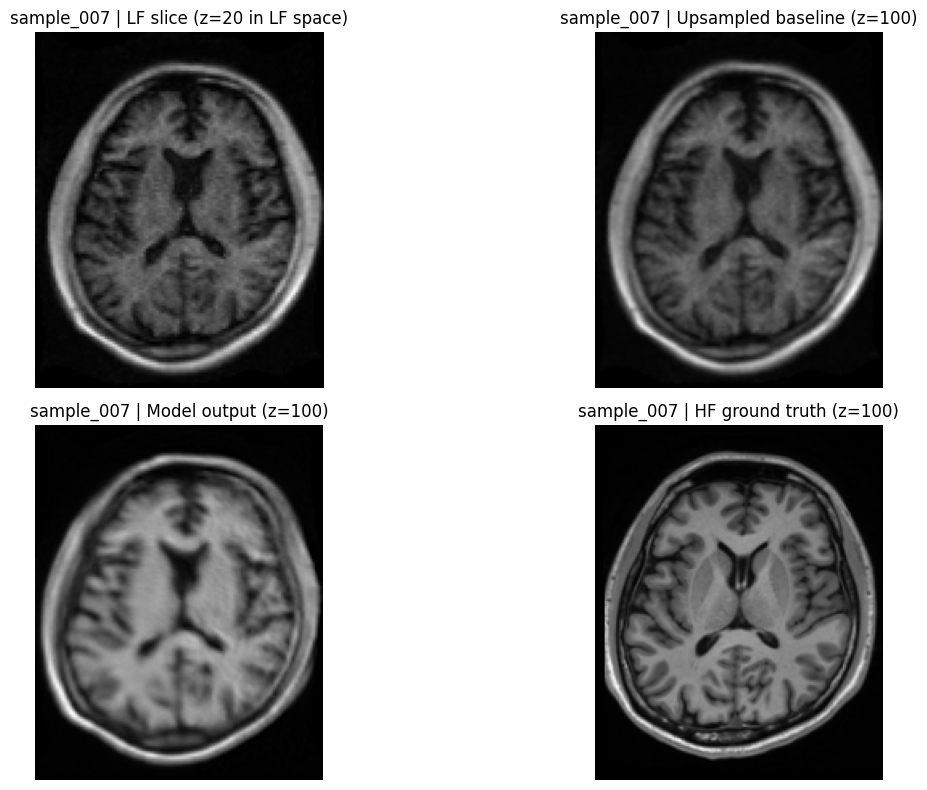

In [17]:
lp, hp, sid = val_pairs[0]
lf_vol = load_nifti(lp)
hf_vol = load_nifti(hp)

show_side_by_side(
    lf_vol=lf_vol,
    hf_vol=hf_vol,
    model=model,
    z=100,
    k=5,
    title_prefix=f"{sid} | "
)
